https://gemini.google.com/share/5534eda61953

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn Modules
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay

# --- ALGORITHM IMPORTS (Keep these handy to swap out) ---
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# ==========================================
# 1. SETUP & DATA SPLITTING
# ==========================================
# (Generating a dummy dataset with mixed types for demonstration)
X_num, y = make_classification(n_samples=500, n_features=10, n_informative=5, random_state=42)
df = pd.DataFrame(X_num, columns=[f'num_feature_{i}' for i in range(10)])
df['cat_feature_1'] = np.random.choice(['A', 'B', 'C'], 500) # Add a categorical column
X = df


1. # **~~_~~`AFTER EDA`~~_~~**

In [6]:
#help(MinMaxScaler)
help(SimpleImputer)

Help on class SimpleImputer in module sklearn.impute._base:

class SimpleImputer(_BaseImputer)
 |  SimpleImputer(
 |      *,
 |      missing_values=nan,
 |      strategy='mean',
 |      fill_value=None,
 |      copy=True,
 |      add_indicator=False,
 |      keep_empty_features=False
 |  )
 |
 |  Univariate imputer for completing missing values with simple strategies.
 |
 |  Replace missing values using a descriptive statistic (e.g. mean, median, or
 |  most frequent) along each column, or using a constant value.
 |
 |  Read more in the :ref:`User Guide <impute>`.
 |
 |  .. versionadded:: 0.20
 |     `SimpleImputer` replaces the previous `sklearn.preprocessing.Imputer`
 |     estimator which is now removed.
 |
 |  Parameters
 |  ----------
 |  missing_values : int, float, str, np.nan, None or pandas.NA, default=np.nan
 |      The placeholder for the missing values. All occurrences of
 |      `missing_values` will be imputed. For pandas' dataframes with
 |      nullable integer dtypes w

In [3]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ==========================================
# 2. THE COLUMN TRANSFORMER (Traffic Router)
# ==========================================
# Identify which columns are numbers and which are categories
numeric_features = [col for col in X.columns if X[col].dtype != 'object']
categorical_features = [col for col in X.columns if X[col].dtype == 'object']


Running Grid Search...
Best Parameters Found: {'classifier__C': 0.1, 'pca__n_components': 5}
Test Set Accuracy: 0.6700


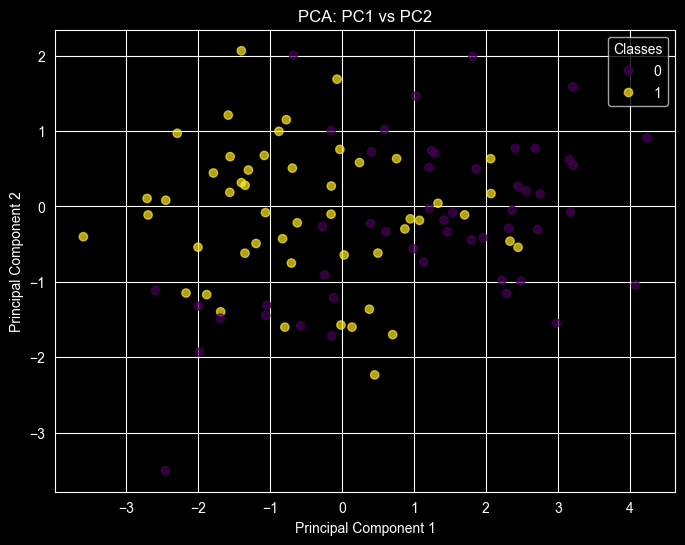

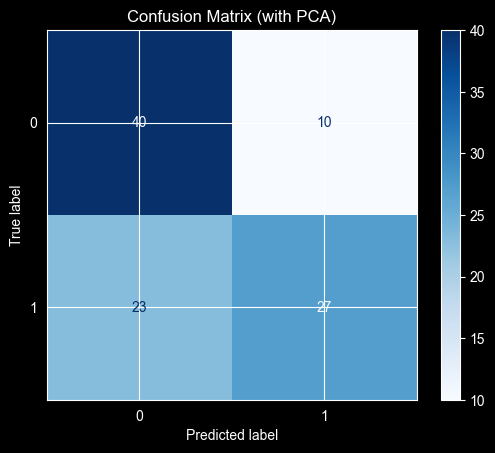

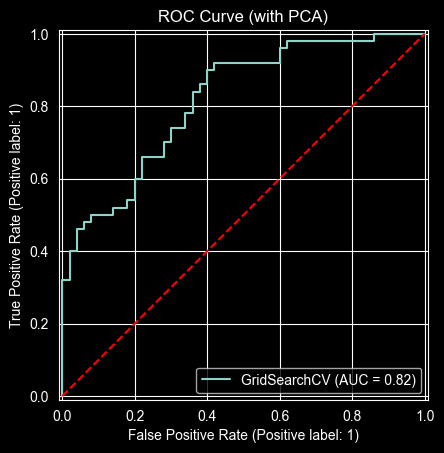

In [5]:

# Lane 1: Numerical Data Pipeline
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')), # Fill missing numbers with median
    ('scaler', StandardScaler())                   # Standardize the numbers
])
# Lane 2: Categorical Data Pipeline
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')), # Fill missing text with mode
    ('ohe', OneHotEncoder(handle_unknown='ignore'))       # Convert text to binary columns
])

# Merge the lanes
#List of (name, transformer, columns) tuples specifying the transformer objects to be applied to subsets of the data
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# ==========================================
# 3. THE MASTER PIPELINE
# ==========================================
pipe = Pipeline([
    ('preprocessor', preprocessor), # 1. Clean and scale everything
   # ('pca', PCA()),                 # 2. Compress the features, not there for portions
    ('classifier', LogisticRegression()) # 3. Train the model

    # --- SWAPPING MODELS FOR EXAMS ---
    # To change models, just change the line above. Examples:
    # ('classifier', SVC(kernel='rbf'))
    # ('classifier', RandomForestClassifier())
    # ('classifier', KNeighborsClassifier())
])

# ==========================================
# 4. GRID SEARCH (Hyperparameter Tuning)
# ==========================================
# Note: You can even tune PCA's parameters here!
param_grid = {
    'pca__n_components': [2, 3, 5], # Test keeping 2, 3, or 5 principal components
    'classifier__C': [0.1, 1.0, 10.0] # Logistic Regression tuning

    # --- SWAPPING PARAMETERS ---
    # If using RandomForest:
    # 'classifier__n_estimators': [50, 100],
    # 'classifier__max_depth': [None, 5, 10]

    # If using KNN:
    # 'classifier__n_neighbors': [3, 5, 7]
}

print("Running Grid Search...")
grid = GridSearchCV(pipe, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X_train, y_train)

print(f"Best Parameters Found: {grid.best_params_}")
print(f"Test Set Accuracy: {grid.score(X_test, y_test):.4f}")

# ==========================================
# 5. POST-EDA VISUALIZATIONS
# ==========================================

# --- A. PCA PLOT (PC1 vs PC2) ---
# Pro-Tip: To plot PCA correctly, we must pass the test data through the pipeline
# *up to the PCA step*, stopping before the classifier.
# grid.best_estimator_[:-1] slices the pipeline to exclude the final classifier step!
# pca_pipeline = grid.best_estimator_[:-1]
# X_test_pca = pca_pipeline.transform(X_test)
#
# plt.figure(figsize=(8, 6))
# # Plot PC1 (column 0) vs PC2 (column 1), colored by the actual target labels
# scatter = plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_test, cmap='viridis', alpha=0.7)
# plt.title("PCA: PC1 vs PC2")
# plt.xlabel("Principal Component 1")
# plt.ylabel("Principal Component 2")
# plt.legend(*scatter.legend_elements(), title="Classes")
# plt.grid(True)
# plt.show()

# --- B. CONFUSION MATRIX ---
ConfusionMatrixDisplay.from_estimator(grid, X_test, y_test, cmap='Blues')
plt.title("Confusion Matrix (with PCA)")
plt.show()

# --- C. ROC CURVE ---
RocCurveDisplay.from_estimator(grid, X_test, y_test)
plt.title("ROC Curve (with PCA)")
plt.plot([0, 1], [0, 1], 'r--') # Add diagonal chance line
plt.show()

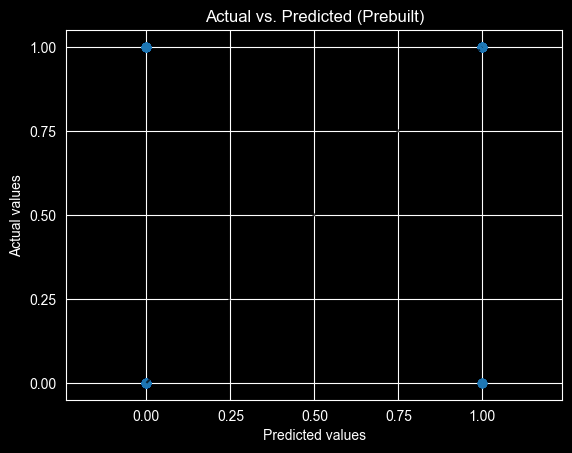

In [8]:
from sklearn.metrics import PredictionErrorDisplay

# 1. Generate the display object
display = PredictionErrorDisplay.from_estimator(
    grid,
    X_test,
    y_test,
    kind="actual_vs_predicted"
)

# 2. Access the 'scatter' object directly to change alpha or color
# This is a safe 'hack' for any scikit-learn display object
plt.setp(display.line_, color='red', linestyle='--') # Format the reference line
plt.title("Actual vs. Predicted")
plt.show()

In [9]:
def report_all_performance(model_grid, X_test, y_test, is_regression=False):
    """
    Pass the grid and data, get all mandatory lab plots instantly.
    """
    import matplotlib.pyplot as plt

    if is_regression:
        from sklearn.metrics import PredictionErrorDisplay
        fig, ax = plt.subplots(1, 2, figsize=(12, 5))

        # Plot 1: Actual vs Predicted
        PredictionErrorDisplay.from_estimator(model_grid, X_test, y_test, kind="actual_vs_predicted", ax=ax[0])
        ax[0].set_title("Actual vs. Predicted")

        # Plot 2: Residuals
        PredictionErrorDisplay.from_estimator(model_grid, X_test, y_test, kind="residual_vs_predicted", ax=ax[1])
        ax[1].set_title("Residuals Plot")

    else:
        from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay
        fig, ax = plt.subplots(1, 2, figsize=(12, 5))

        # Plot 1: Confusion Matrix
        ConfusionMatrixDisplay.from_estimator(model_grid, X_test, y_test, cmap='Blues', ax=ax[0])
        ax[0].set_title("Confusion Matrix")

        # Plot 2: ROC Curve
        RocCurveDisplay.from_estimator(model_grid, X_test, y_test, ax=ax[1])
        ax[1].plot([0, 1], [0, 1], 'r--')
        ax[1].set_title("ROC Curve")

    plt.tight_layout()
    plt.show()

# USAGE IN EXAM:
# For Exp 2 & 4: report_all_performance(grid, X_test, y_test, is_regression=False)
# For Exp 3: report_all_performance(grid, X_test, y_test, is_regression=True)

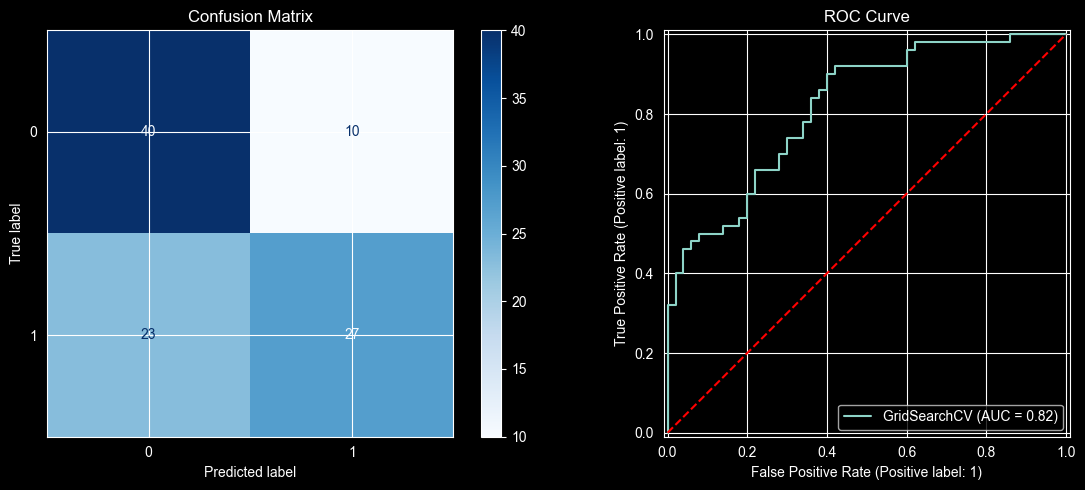

In [10]:
report_all_performance(grid, X_test, y_test, is_regression=False)